# 定理25　諸法無我定理（縁起の数理）— 数値で見る例

> **この notebook の位置づけ。** 数値シミュレーション（説明用のトイ例）で、証明ではありません。
> Lean で確かめた範囲は最後の「Lean との対応」に書きます。原文の主張・この例が見せること・仏教的な読み（解釈）は別の見出しに分けます。
> 定理25は四法印の3つ目（**諸法無我**）です。**仏教語の思想的な解釈と、形式化された数理結論は別物** として読んでください。

## 1. 定理25は何を言っているのか

### 原文の主張（二段の主張）

「諸法無我」は2段からなります。**第一**：すべての存在は、それだけで自存しているのではなく、互いに繋がり合って成り立っている（**縁起**）。**第二**：だから、他の存在・歩んできた履歴・層のあいだの関係から **独立した固定の「自分」という実体は、どこにも存在しない**。

数式では2つの結論になります（条件25-A〜25-D のもとで）。

$$
\neg\exists S_0\ \forall h:\ F_{i,h}(S_0)=S_0
\qquad\text{かつ}\qquad
\forall d\in\mathfrak D\ \forall\alpha\in\mathbb L:\ \neg\,\mathrm{Atman}(d,\alpha).
$$

* **(25.1)** **全履歴に共通する固定点 $S_0$ は存在しない。** 定理16が示したのは **履歴 $h$ ごとの** 固定点 $S^*_{i,h}$ の存在でした。履歴が違えば固定点も違う（条件25-A）。共通の芯は無い。
* **(25.2)** **いかなる存在・いかなる層にも、固定的な自性 $\mathrm{Atman}(d,\alpha)$ は無い。** $\mathrm{Atman}(d,\alpha)$ は「関係から独立に $d$ を固定し、**余分の因果力** までもつ自性がある」という命題です。

### 証明の心（二段構えの背理法）

* **第一段：** 全履歴共通の固定点 $S_0$ があるとすると、履歴が違えば固定点は違う（条件25-A）ことに矛盾。よって (25.1)。
* **第二段：** ある $d,\alpha$ に固定的自性 $\mathrm{Atman}(d,\alpha)$ があるとし、その候補 $\Sigma$ をつまんで **差し替える**（$do(\Sigma\to\Sigma')$ という「**もし変えたら**」テスト）。
  * 未来の出力が **変わる** なら、$\Sigma$ は関係的状態 $\Gamma_{d,\alpha}$ の **外** で効いたことになり、**条件25-D（関係的機能完備性）** に反する。
  * **変わらない** なら、余分の因果力を欠き、Atman の定義を満たさない。
  * どちらでも矛盾。よって (25.2)。

### 原文の最も大事な但し書き

> 無我を導く **決定条件** は、包摂グラフや父母子関係が「ある」ことではない（連結グラフの各点に固有の固定属性を付けることは数学的に可能だから）。決定条件は、**全法・全層に量化された関係的機能完備性（25-D）** である。

つまり **「つながっている」だけでは無我は出ません**。25-D（**関係的な状態 $\Gamma$ で、機能的に説明が尽きている**）が要ります。

### 条件25-C（双方向縁起関係）と父母子の例

関係は **逆役割の対** で成り立ちます：$((d,\alpha),r,(e,\beta))\in E_{\mathrm{rel}}\Longleftrightarrow((e,\beta),r^{\smile},(d,\alpha))\in E_{\mathrm{rel}}$。父母子の例（25.C）：$\mathrm{FatherOf}(f,c;h)\Leftrightarrow\mathrm{HasFather}(c,f;h)$（「父である」と「父をもつ」は同じ縁を両端から読んだ逆役割の対）、$\forall c\ \exists f,m$（生まれた者にはかならず父と母がいる）。

### 記号とコード変数の対応

| 原文の記号 | 意味 | このコードでは |
| --- | --- | --- |
| 履歴 $h\in\{0,1,2\}$ | 3通りの履歴 | `h` |
| フィードバック $F_h(S)=(1-L)c_h+LS$ | 履歴ごとの縮小写像（$\mathbb R^2$、$L=0.6$） | `F` |
| 固定点 $S^*_h=c_h$ | 履歴ごとの固定点 | `c[h]` |
| 関係的状態 $\Gamma\in\{0,1\}^2$ | 2つの関係の有無（一様分布） | `(g1, g2)` |
| 候補自性 $\Sigma\in\mathbb Z$ | 基準は $\Sigma=0$ | `s`（`cands`） |
| 出力 $Y=\Gamma_1-\Gamma_2+\beta\Sigma$ | $\beta$ は $\Sigma$ が出力に効く強さ | `law(beta, s)` |
| 介入 $do(\Sigma=s)$ | $\Sigma$ を $s$ に差し替える | `law(beta, s)` |

## 2. なぜこれが「定理25の例」と言えるのか

* **(A) 履歴相対の固定点（(25.1) の核）。** 3つの履歴それぞれに縮小写像 $F_h$ があり、固定点は別々（$c_0=(0.1,0.9),\ c_1=(0.8,0.2),\ c_2=(0.5,0.5)$）。**固定点が履歴ごとに違う** なら、全部に共通の固定点は存在しません。
* **(B) 25-D の成立・不成立（(25.2) の核）。** 有限の因果モデル（決定論的）で、$do(\Sigma=s)$ の後の $(\Gamma,Y)$ の **同時法則** を、4通りの事象を **全部列挙して厳密に** 求め、基準（$\Sigma=0$）の法則と比べます。
  * **$\beta=0$**（$Y=\Gamma_1-\Gamma_2$、$\Sigma$ は出力に効かない）：どの $s$ でも法則は **不変**。**25-D 成立** → $\Sigma$ は冗長 → **Atman ではない**。
  * **$\beta=1$**（$Y=\Gamma_1-\Gamma_2+\Sigma$、$\Sigma$ が出力に効く）：$do(\Sigma=2)$ で法則が **変わる**（$\{Y=2\}$ の確率が $0\to\tfrac12$）。**25-D 不成立** → $\Sigma$ は $\Gamma$ の外で効く「自性」になってしまう。**定理25の前提（25-D）が破れた場合の挙動** です。
* **(C) 逆役割関係と連結性。** 父・母・子の関係を逆役割のラベルで持ち、水平の関係グラフが連結であることを確かめます（条件25-C の例）。**ただしこれだけでは無我は導けません**（但し書き参照）。

## 3. 3つの計算

In [1]:
# %% 準備
import numpy as np
import matplotlib.pyplot as plt
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)  # フォント警告を抑制
try:
    import japanize_matplotlib  # Colab: !pip -q install japanize-matplotlib
except Exception:
    plt.rcParams["font.family"] = ["Noto Sans CJK JP", "IPAexGothic", "sans-serif"]

# --- (A) ---
L = 0.6
c = {0: np.array([0.1, 0.9]), 1: np.array([0.8, 0.2]), 2: np.array([0.5, 0.5])}
F = lambda h, S: (1 - L) * c[h] + L * S
def iterate(h, S0, n=60):
    S = np.array(S0, float); path = [S.copy()]
    for _ in range(n): S = F(h, S); path.append(S.copy())
    return np.array(path)
paths = {h: iterate(h, [0.3, 0.3]) for h in c}
common = [S for S in (np.array([a, b]) for a in np.linspace(0, 1, 101) for b in np.linspace(0, 1, 101))
          if all(np.allclose(F(h, S), S, atol=1e-9) for h in c)]

# --- (B) ---
from collections import Counter
from fractions import Fraction
def law(beta, s):                                # do(Σ=s) 後の (Γ,Y) の厳密な同時法則
    cnt = Counter(((g1, g2), int(g1) - int(g2) + beta * s) for g1 in (0, 1) for g2 in (0, 1))
    return {k: Fraction(v, 4) for k, v in cnt.items()}
cands = [-1, 0, 1, 2]
invariant = {beta: all(law(beta, s) == law(beta, 0) for s in cands) for beta in (0, 1)}   # 25-D
p_y2 = {beta: (float(sum(p for (g, y), p in law(beta, 2).items() if y == 2)),
               float(sum(p for (g, y), p in law(beta, 0).items() if y == 2))) for beta in (0, 1)}

# --- (C) ---
people = ["祖父", "父", "母", "子", "叔母"]
father_of = {("祖父", "父"), ("父", "子")}; mother_of = {("母", "子"), ("祖母", "叔母")}
has_father = {(c_, f) for f, c_ in father_of}                       # 逆役割ラベル
edges = [(a, b) for a, b in father_of | mother_of | {("父", "叔母")}] # 叔母は父の姉妹 → 関係辺を1本足す
adj = {p: set() for p in people + ["祖母"]}
for a, b in edges: adj[a].add(b); adj[b].add(a)
seen, stack = set(), ["祖父"]
while stack:
    p = stack.pop()
    if p not in seen: seen.add(p); stack.extend(adj[p])
connected = seen == set(adj)

* **(A)** `iterate(h, S0)` は履歴 $h$ のフィードバックを 60 回繰り返し、`paths` に軌道を記録。`common` は、$[0,1]^2$ の 101×101 格子点のうち **すべての履歴で固定される点** のリスト。
* **(B)** `law(beta, s)` は分数（`Fraction`）で正確な法則を返します。`invariant` は 25-D（全候補 $s$ で法則が基準 $s=0$ と一致）の成否。`p_y2` は $do(\Sigma=2)$ のときと基準の $P(Y=2)$。
* **(C)** 父・母の関係を逆役割で記録し、グラフの連結性を探索で調べます。

## 4. 図を読む

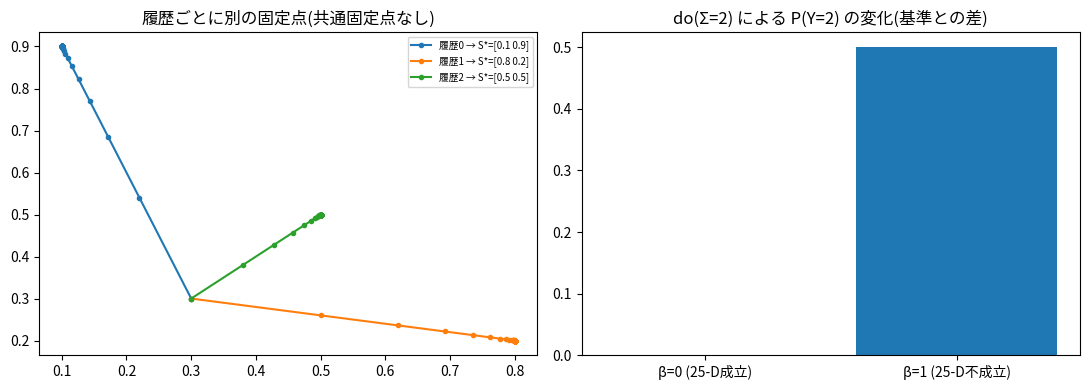

In [2]:
# %% 可視化
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for h, p in paths.items(): ax[0].plot(p[:, 0], p[:, 1], "o-", ms=3, label=f"履歴{h} → S*={c[h]}")
ax[0].set_title("履歴ごとに別の固定点(共通固定点なし)"); ax[0].legend(fontsize=7)
ax[1].bar(["β=0 (25-D成立)", "β=1 (25-D不成立)"], [p_y2[0][0] - p_y2[0][1], p_y2[1][0] - p_y2[1][1]])
ax[1].set_title("do(Σ=2) による P(Y=2) の変化(基準との差)")
plt.tight_layout(); plt.show()

### 左：履歴ごとに別の固定点

3つの履歴の軌道を、すべて同じ出発点 $S_0=(0.3,\,0.3)$ から描いています。
* **青（履歴0）：** $(0.3,0.3)$ から左上へ向かい、**$(0.1,0.9)$** に収束。
* **橙（履歴1）：** 右下へ向かい、**$(0.8,0.2)$** に収束。
* **緑（履歴2）：** 右上へ向かい、**$(0.5,0.5)$** に収束。

**同じ出発点でも、履歴が違えば行き着く先（固定点）が違います。** 3つの固定点は互いに異なるので、3つの履歴 **すべてに共通の固定点は存在しません**（出力の「共通固定点の個数：0」。ただしこれは格子上の探索です。**存在しないことの証明は、固定点が相異なること**（$c_h$ が異なる）から出ます）。
定理16が示した「履歴つきの固定点は在る」は、この図の3つの収束点です。

### 右：$do(\Sigma=2)$ による $P(Y=2)$ の変化

棒は「$do(\Sigma=2)$ のときの $P(Y=2)$」から「基準（$\Sigma=0$）のときの $P(Y=2)$」を引いた差です。
* **$\beta=0$（25-D 成立）：差は $0$**。棒がありません。$\Sigma$ を差し替えても何も変わらない。
* **$\beta=1$（25-D 不成立）：差は $0.5$**。$\Sigma$ を $2$ に差し替えると、$Y=2$ が出る確率が $0$ から $\tfrac12$ に変わる。基準では $Y=\Gamma_1-\Gamma_2\in\{-1,0,1\}$ で $Y=2$ は **出ない**（確率 $0$）が、$do(\Sigma=2)$ では $Y=\Gamma_1-\Gamma_2+2=2$ となるのは $\Gamma_1=\Gamma_2$ のとき（確率 $\tfrac12$）。

つまり $\beta=1$ では、**関係的状態 $\Gamma$ だけでは出力が説明し切れず**、$\Sigma$ が $\Gamma$ の外で余分に効いています。これが「**固定的な自性が残る**」状況で、25-D がそれを排除する条件です。

## 5. 数値確認

In [3]:
# %% 数値確認
print("共通固定点の個数:", len(common), " 25-D(法則不変):", invariant, " P(Y=2) [do(Σ=2), 基準]:", p_y2, " 関係グラフ連結:", connected)
assert all(np.allclose(paths[h][-1], c[h], atol=1e-9) for h in c) and len(common) == 0
assert invariant == {0: True, 1: False} and p_y2[0] == (0.0, 0.0) and p_y2[1] == (0.5, 0.0)
assert ("子", "父") in has_father and connected

共通固定点の個数: 0  25-D(法則不変): {0: True, 1: False}  P(Y=2) [do(Σ=2), 基準]: {0: (0.0, 0.0), 1: (0.5, 0.0)}  関係グラフ連結: True


出力：「共通固定点の個数：$0$、25-D（法則不変）：$\{0:\text{True},\ 1:\text{False}\}$、$P(Y=2)$（$do(\Sigma=2)$、基準）：$\{0:(0.0,0.0),\ 1:(0.5,0.0)\}$、関係グラフ連結：True」。

## 6. 仏教的な意義（解釈）

> 原文の説明にそった **思想的な読み** で、Lean で形式化された数理結論そのものではありません。

* **「その都度の自分」は実在し、「不変の芯」は実在しない。** 原文の整合性確認②：定理16が証明するのは **履歴つきの固定点** $S^*_h$、定理25が否定するのは **全履歴共通の $S_0$**。左の図の3つの収束点（履歴ごとの自分）は実在し、それらに共通する不動の芯は無い。
* **縁起＝関係の網。** 原文は父母子の例で、「父は、息子や娘がいるから父である」と説明します（逆役割の対）。すべての存在は縁の網の中でだけ、その「何であるか」を得る。
* **「つながり」では足りない。** 25-D（関係的な機能で説明が尽きること）が決定条件です。右の図の $\beta=1$ は、関係以外に効く何か（余分の因果力）があるモデルで、その場合は無我は出ません。**無我は「つながっているから」ではなく、「関係の外に余分の効き方が無いから」** という主張です。
* **責任は消えない（原文Q&A）。** 「行為の因果は履歴を通って現実に効く。消えたのは入力と無関係の固定した犯人であって、履歴を担う機能的な行為者ではない」。
* 原文は、死後と記憶、空 $\top$ での個体の識別内容の消失（★$_\top$）にも触れますが、この例の範囲外です。

## 7. Lean との対応

対応ファイル：`Tomabechi/Examples/Theorem25_NoSelf.lean`（`scm_zero_no_atman`・`scm_one_has_atman`、履歴別縮小写像、逆役割関係と連結性）。

| | 内容 | 状態 |
| --- | --- | --- |
| (A) | 履歴別の縮小写像があり、**共通固定点は存在しない** | 証明済 |
| (B) | 有限 SCM で、$\beta=0\Rightarrow$ 25-D 成立 $\Rightarrow$ Atman なし、$\beta=1\Rightarrow$ 25-D 不成立 $\Rightarrow$ Atman 成立 | 証明済（**有限モデル**） |
| (C) | 逆役割関係と連結性 | 証明済 |
| 一般の存在・層（$\mathfrak D$、$\mathbb L$）に量化した定理の適用 | 本例では行っていない | 有限モデルの範囲のみ |

* (B) は、もとの Python（連続ノイズ）を **有限値・決定論的** に変更しました。Lean で全事象を列挙して厳密に示すためです。
* (B) の $\beta=1$ は「条件25-D が破れる場合」で、定理25の反例ではありません（定理は25-D を仮定しています）。
* 連結性（C）だけからは無我は出ません。**決定的なのは 25-D** です。